# CartPole


## 1. Imports

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import numpy as np
from collections import deque
from IPython.display import clear_output
import matplotlib.pyplot as plt

## 2. Neural Network
Simple 3-layer network: takes 4 cart state values, outputs Q-values for 2 actions (left/right).

In [3]:
class CartPoleBrain(nn.Module):
    def __init__(self):
        super(CartPoleBrain, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, state):
        return self.network(state)


def optimize_model(policy_net, target_net, optimizer,
                   states, actions, rewards, next_states, dones, gamma=0.99):
    # Q-values for actions actually taken
    q_values = policy_net(states).gather(1, actions)

    # Target Q-values from target network
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)

    # Bellman equation: if done, no future reward
    target_q_values = rewards + (gamma * next_q_values * (1 - dones))

    # Huber loss (robust to outliers)
    loss = F.smooth_l1_loss(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 1)  # prevent exploding gradients
    optimizer.step()

    return loss.item()

## 3. Hyperparameters

In [4]:
BATCH_SIZE    = 128
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_END   = 0.02
EPSILON_DECAY = 20000
LR            = 5e-4
TARGET_UPDATE = 30      # how many episodes between target network sync
MEMORY_SIZE   = 50000
NUM_EPISODES  = 2000
PLOT_EVERY    = 200     # how often to refresh the live plot

## 4. Setup Environment & Networks

In [5]:

env = gym.make("CartPole-v1")

policy_net = CartPoleBrain()
target_net = CartPoleBrain()
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory    = deque(maxlen=MEMORY_SIZE)
steps_done = 0

## 5. Helper Functions

In [6]:
def select_action(state):
    global steps_done
    # calc probability of exploring (epsilon)
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-1. * steps_done / EPSILON_DECAY)
    steps_done += 1

    # take a random step
    if random.random() < epsilon:
        return env.action_space.sample()  # explore
    else: # take a step based on our network
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            return policy_net(state_tensor).argmax().item()  # exploit


def plot_progress(scores, best_avg, episode):
    rolling_avg = [np.mean(scores[max(0, i-50):i+1]) for i in range(len(scores))]
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(scores, alpha=0.3, color='steelblue', label='Episode Score')
    ax.plot(rolling_avg, color='orange', linewidth=2, label='Rolling Avg (50)')
    ax.axhline(475, color='red', linestyle='--', label='Solved (475)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Score')
    ax.set_title(f'DQN Training — Episode {episode} | Best Avg: {best_avg:.1f} | Current Avg: {rolling_avg[-1]:.1f}')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

## 6. Training Loop

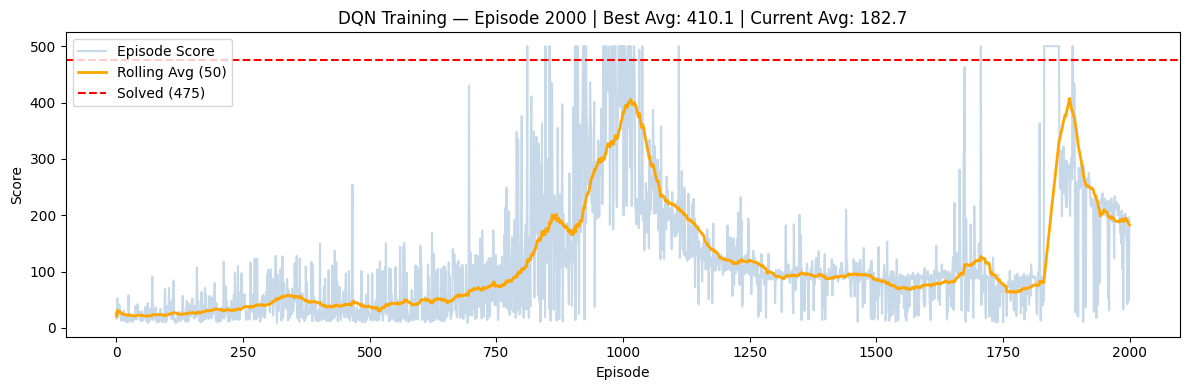


 Training complete!
   Best rolling avg : 410.1
   Final rolling avg: 181.9
   Best model saved : cartpole_best.pth


In [7]:
scores   = []
best_avg = 0

for episode in range(NUM_EPISODES):
    state, info = env.reset()
    total_reward = 0

    while True:
        action = select_action(state) # select action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        memory.append((state, action, reward, next_state, float(done))) # add for batch
        state = next_state # go to next state
        total_reward += reward # add whatever the reward is to total reward

        # Train
        if len(memory) >= BATCH_SIZE:
            # sample from our batch (mini-batch gradient descent)
            transitions = random.sample(memory, BATCH_SIZE)
            # turn tuples into lists based on category
            batch_state, batch_action, batch_reward, batch_next_state, batch_done = zip(*transitions)

            # variables ---> pytorch tensors (inputs into network)
            state_tensor      = torch.tensor(np.array(batch_state),      dtype=torch.float32)
            action_tensor     = torch.tensor(batch_action,               dtype=torch.int64).unsqueeze(1)
            reward_tensor     = torch.tensor(batch_reward,               dtype=torch.float32).unsqueeze(1)
            next_state_tensor = torch.tensor(np.array(batch_next_state), dtype=torch.float32)
            done_tensor       = torch.tensor(batch_done,                 dtype=torch.float32).unsqueeze(1)

            # optimize using values
            optimize_model(
                policy_net, target_net, optimizer,
                state_tensor, action_tensor, reward_tensor,
                next_state_tensor, done_tensor, gamma=GAMMA
            )

        if done:
            break

    scores.append(total_reward)

    # Sync target network (skip episode 0)
    if episode > 0 and episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Save best model
    current_avg = np.mean(scores[-50:])
    if current_avg > best_avg:
        best_avg = current_avg
        torch.save(policy_net.state_dict(), "cartpole_best.pth")

    # Live plot
    if episode % PLOT_EVERY == 0 and episode > 0:
        plot_progress(scores, best_avg, episode)

env.close()

# Final plot
plot_progress(scores, best_avg, NUM_EPISODES)
print(f"\n Training complete!")
print(f"   Best rolling avg : {best_avg:.1f}")
print(f"   Final rolling avg: {np.mean(scores[-50:]):.1f}")
print(f"   Best model saved : cartpole_best.pth")

## 7. Load Best Model
Run this to restore the best checkpoint saved during training.

In [8]:
policy_net.load_state_dict(torch.load("cartpole_best.pth"))
policy_net.eval()
print("✅ Best model loaded")

✅ Best model loaded


## 8. Evaluate
Runs the trained agent

In [ ]:
EVAL_EPISODES = 10
eval_env = gym.make("CartPole-v1", render_mode="human")
eval_scores = []

for episode in range(EVAL_EPISODES):
    state, info = eval_env.reset()
    total_reward = 0

    while True:
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            action = policy_net(state_tensor).argmax().item()

        state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    eval_scores.append(total_reward)
    print(f"Eval episode {episode + 1:02d}: {total_reward:.0f}")

eval_env.close()

print(f"\n Avg: {np.mean(eval_scores):.1f}  |  Min: {min(eval_scores):.0f}  |  Max: {max(eval_scores):.0f}")

Eval episode 01: 500
Eval episode 02: 427
Eval episode 03: 500
Eval episode 04: 424
Eval episode 05: 427
Eval episode 06: 420
Eval episode 07: 431
Eval episode 08: 422
